# The TF2 version of the object detection

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import keras_cv
from PIL import Image
from PIL import ImageDraw
from PIL import ImageColor
import time
from scipy.stats import norm

2026-02-22 22:39:31.569628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771796371.588530   14080 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771796371.594144   14080 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771796371.610080   14080 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771796371.610111   14080 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771796371.610114   14080 computation_placer.cc:177] computation placer alr

In [2]:
image_dir = "./assets/sample1.jpg"
image = mpimg.imread(image_dir)

## Define Helper Functions

In [3]:
image.shape
image = tf.reshape(image, [1, *image.shape])
image.shape

I0000 00:00:1771796378.621298   14080 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6096 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


TensorShape([1, 636, 1024, 3])

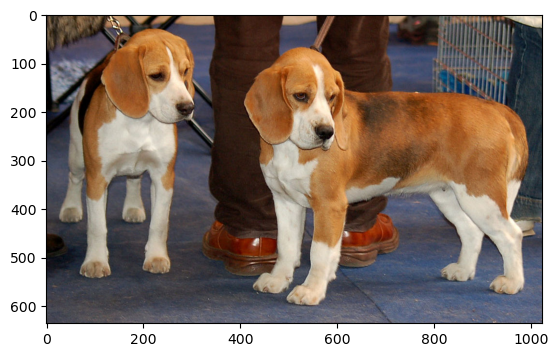

In [4]:
plt.imshow(image[0])
plt.show()

In [5]:
# Colors (one for each class)
cmap = ImageColor.colormap
print("Number of colors =", len(cmap))
COLOR_LIST = sorted([c for c in cmap.keys()])

#
# Utility funcs
#

def filter_boxes(min_score, boxes, scores, classes):
    """Return boxes with a confidence >= `min_score`"""
    n = len(classes)
    idxs = []
    for i in range(n):
        if scores[i] >= min_score:
            idxs.append(i)
    
    filtered_boxes = boxes[idxs, ...]
    filtered_scores = scores[idxs, ...]
    filtered_classes = classes[idxs, ...]
    return filtered_boxes, filtered_scores, filtered_classes

def to_image_coords(boxes, height, width):
    """
    The original box coordinate output is normalized, i.e [0, 1].
    
    This converts it back to the original coordinate based on the image
    size.
    """
    box_coords = np.zeros_like(boxes)
    box_coords[:, 0] = boxes[:, 0] * height
    box_coords[:, 1] = boxes[:, 1] * width
    box_coords[:, 2] = boxes[:, 2] * height
    box_coords[:, 3] = boxes[:, 3] * width
    
    return box_coords

def draw_boxes(image, boxes, classes, thickness=4):
    """Draw bounding boxes on the image"""
    draw = ImageDraw.Draw(image)
    for i in range(len(boxes)):
        bot, left, top, right = boxes[i, ...]
        class_id = int(classes[i])
        color = COLOR_LIST[class_id]
        draw.line([(left, top), (left, bot), (right, bot), (right, top), (left, top)], width=thickness, fill=color)

Number of colors = 148


## Using Tensorflow Keras CV

In [6]:
model = keras_cv.models.object_detection.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

ConnectionError: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/models.ModelApiService/DownloadModelInstanceVersion (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x792af41dd650>: Failed to resolve 'api.kaggle.com' ([Errno -3] Temporary failure in name resolution)"))

In [7]:
dir(keras_cv.models.object_detection)

['RetinaNet',
 'YOLOV8Detector',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']

In [ ]:
model = tf.keras.models.load_model("./ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model/saved_model.pb")

In [8]:
model = tf.keras.layers.TFSMLayer("./ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model", call_endpoint='serving_default')

In [10]:
(boxes, scores, classes) = model(inputs=image, training=False)

ValueError: too many values to unpack (expected 3)

In [ ]:
#prediction

# Remove unnecessary dimensions
boxes = np.squeeze(boxes)
scores = np.squeeze(scores)
classes = np.squeeze(classes)

confidence_cutoff = 0.8
# Filter boxes with a confidence score less than `confidence_cutoff`
boxes, scores, classes = filter_boxes(confidence_cutoff, boxes, scores, classes)

# The current box coordinates are normalized to a range between 0 and 1.
# This converts the coordinates actual location on the image.
width, height = image.size
box_coords = to_image_coords(boxes, height, width)

# Each class with be represented by a differently colored box
draw_boxes(image, box_coords, classes)

plt.figure(figsize=(12, 8))
plt.imshow(image) 